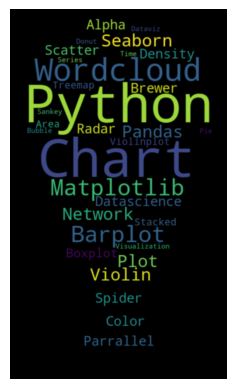

In [1]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt
file_name= "bg_white_bulb.png"
# Load your light bulb mask image
bulb_mask = np.array(Image.open(file_name))

# Define your text data
# text = "innovation idea creativity brain technology lightbulb focus design smart future"
text=("Python Python Python Matplotlib Matplotlib Seaborn Network Plot Violin Chart Pandas Datascience Wordcloud Spider Radar Parrallel Alpha Color Brewer Density Scatter Barplot Barplot Boxplot Violinplot Treemap Stacked Area Chart Chart Visualization Dataviz Donut Pie Time-Series Wordcloud Wordcloud Sankey Bubble")

# wc = WordCloud (width=420,height=200,mask=bulb_mask,margin=0,contour_width=2,background_color='black',colormap='Accent',mode='RGBA')

# Generate the word cloud inside the mask boundary
wc=WordCloud(margin=2, mask=bulb_mask,contour_width=2,background_color='white',colormap='Accent',mode='RGBA')

wc = WordCloud(background_color="black", mask=bulb_mask, contour_width=0, contour_color='white')
wc.generate(text)

# Display your creation
plt.imshow(wc, interpolation='quadric')
plt.axis("off")
plt.show()

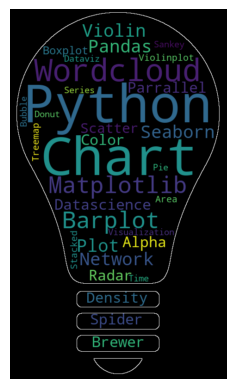

In [47]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Load image and convert to grayscale ('L')
mask_img = Image.open(file_name).convert("L")

# 2. Force any non-black/gray background pixel to be pure white (255)
mask_array = np.array(mask_img)
mask_array[mask_array > 240] = 255  # Adjust 240 lower if bleeding persists

# 3. Generate the word cloud
# text = "innovation idea creativity brain technology lightbulb focus design smart future"
wc = WordCloud(background_color="black", mask=mask_array, contour_width=1, contour_color='white')
wc.generate(text)

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


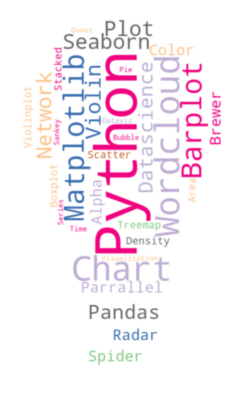

In [50]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Load image and force convert to Grayscale ('L')
# This collapses RGB channels into a single 0-255 brightness channel
mask_img = Image.open(file_name)
mask_array = np.array(mask_img)

# 2. Critical Step: Clean the background noise
# Any pixel that is mostly white (> 200) gets forced to EXACTLY 255
mask_array[mask_array > 200] = 255


#  Generate with safety margins
# 'prefer_horizontal=0.9' ensures words turn vertically if they don't fit the bulb base
wc = WordCloud(
    background_color="white", 
    mask=mask_array, 
    prefer_horizontal=0.9,
    min_font_size=4,
    max_font_size=120,

    colormap='Accent',
    mode='RGBA'
)
wc.generate(text)

# Display the result
plt.figure(figsize=(5, 5))
plt.imshow(wc, interpolation='bicubic')
plt.axis("off")
plt.show()


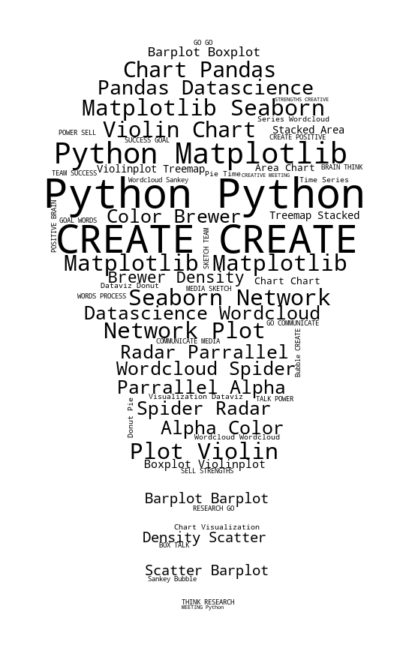

In [ ]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Load your perfect light bulb image and convert to grayscale ('L')
mask_img = Image.open(file_name).convert("L")
mask_array = np.array(mask_img)

# 2. Safety step to clean any transparent or off-white background pixels
# This forces the background to be exactly 255 (the wordcloud ignore value)
mask_cleaned = np.where(mask_array > 150, 255, 0).astype(np.uint8)

# 3. Text data to fill the shape
text1 = """
CREATE CREATE CREATE POSITIVE BRAIN THINK RESEARCH GO GO 
COMMUNICATE MEDIA SKETCH TEAM SUCCESS GOAL WORDS PROCESS 
OUT OF THE BOX TALK POWER SELL STRENGTHS CREATIVE MEETING
""" 


# 4. Configure WordCloud parameters tailored specifically to this shape
wc = WordCloud(
    background_color="white",
    mask=mask_cleaned,
    max_words=200,
    min_font_size=6,             # Low minimum size lets text fit the narrow base segments
    max_font_size=128,           # High maximum size allows big focal words at the top
    prefer_horizontal=0.85,      # Rotates 15% of words vertically to maximize shape density
    collocations=True            # Keeps multi-word phrases together
)

# 5. Generate and fit the text into the bulb
wc.generate((text + text1)*20)

# 6. Apply a clean uniform black color styling to match the reference look
def black_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "black"

wc.recolor(color_func=black_color_func)

# 7. Render and save the final word cloud image
plt.figure(figsize=(4, 2), dpi=300)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)

# Save the final file
plt.savefig("final_bulb_wordcloud.png", bbox_inches='tight', dpi=300)
plt.show()


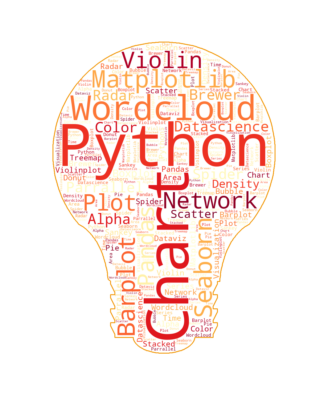

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from wordcloud import WordCloud

# 1. Define your input text
text = ("Python Python Python Matplotlib Matplotlib Seaborn Network Plot Violin Chart "
        "Pandas Datascience Wordcloud Spider Radar Parrallel Alpha Color Brewer Density "
        "Scatter Barplot Barplot Boxplot Violinplot Treemap Stacked Area Chart Chart "
        "Visualization Dataviz Donut Pie Time-Series Wordcloud Wordcloud Sankey Bubble")

# 2. Function to programmatically draw a light bulb mask
def create_lightbulb_mask(width=1000, height=1300):
    # Create white canvas (255 = background/outside shape)
    img = Image.new("L", (width, height), 255)
    draw = ImageDraw.Draw(img)
    
    center_x = width / 2.0
    r_bulb = width * 0.36
    cy_bulb = height * 0.36
    
    path = []
    
    # Bulb top dome arc
    for angle in np.linspace(220, -40, 150):
        rad = np.radians(angle)
        path.append((center_x + r_bulb * np.cos(rad), cy_bulb - r_bulb * np.sin(rad)))
        
    # Right neck transition (Bezier curve)
    base_top_y = height * 0.68
    base_width = width * 0.18
    right_start = path[-1]
    right_end = (center_x + base_width, base_top_y)
    cp1 = (center_x + r_bulb * 0.65, cy_bulb + r_bulb * 0.7)
    cp2 = (center_x + base_width * 1.05, base_top_y - height * 0.08)
    
    for t in np.linspace(0, 1, 50)[1:]:
        x = (1-t)**3 * right_start[0] + 3*(1-t)**2*t * cp1[0] + 3*(1-t)*t**2 * cp2[0] + t**3 * right_end[0]
        y = (1-t)**3 * right_start[1] + 3*(1-t)**2*t * cp1[1] + 3*(1-t)*t**2 * cp2[1] + t**3 * right_end[1]
        path.append((x, y))
        
    # Screw base threads (right side)
    thread_height = height * 0.035
    num_threads = 4
    current_y = base_top_y
    for _ in range(num_threads):
        path.append((center_x + base_width * 0.96, current_y))
        path.append((center_x + base_width * 0.96, current_y + thread_height * 0.2))
        path.append((center_x + base_width * 0.88, current_y + thread_height * 0.8))
        path.append((center_x + base_width * 0.88, current_y + thread_height))
        current_y += thread_height
        
    # Bottom contact point
    contact_r_x = base_width * 0.55
    contact_h = height * 0.04
    for angle in np.linspace(0, -180, 30):
        rad = np.radians(angle)
        path.append((center_x + contact_r_x * np.cos(rad), current_y + contact_h * (-np.sin(rad))))
        
    # Screw base threads (left side going up)
    current_y = base_top_y + num_threads * thread_height
    for _ in range(num_threads):
        current_y -= thread_height
        path.append((center_x - base_width * 0.88, current_y + thread_height))
        path.append((center_x - base_width * 0.88, current_y + thread_height * 0.8))
        path.append((center_x - base_width * 0.96, current_y + thread_height * 0.2))
        path.append((center_x - base_width * 0.96, current_y))
        
    # Left neck transition
    left_start = (center_x - base_width, base_top_y)
    left_end = path[0]
    cp1_l = (center_x - base_width * 1.05, base_top_y - height * 0.08)
    cp2_l = (center_x - r_bulb * 0.65, cy_bulb + r_bulb * 0.7)
    
    for t in np.linspace(0, 1, 50)[1:-1]:
        x = (1-t)**3 * left_start[0] + 3*(1-t)**2*t * cp1_l[0] + 3*(1-t)*t**2 * cp2_l[0] + t**3 * left_end[0]
        y = (1-t)**3 * left_start[1] + 3*(1-t)**2*t * cp1_l[1] + 3*(1-t)*t**2 * cp2_l[1] + t**3 * left_end[1]
        path.append((x, y))
        
    # Fill inner area with black (0 = inside shape)
    draw.polygon(path, fill=0)
    return np.array(img)

# 3. Generate the mask
bulb_mask = create_lightbulb_mask()

# 4. Generate the word cloud
wc = WordCloud(
    background_color="white",
    mask=bulb_mask,
    repeat=True,            # Repeats text to fill the bulb density nicely
    colormap="YlOrRd_r",    # Warm glowing color palette
    contour_width=2,        # Draws a light bulb border
    contour_color="#f39c12",
    min_font_size=8,
    max_words=350,
    random_state=42
).generate(text)

# 5. Display and save the plot
plt.figure(figsize=(8, 4), facecolor='white')
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig("lightbulb_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

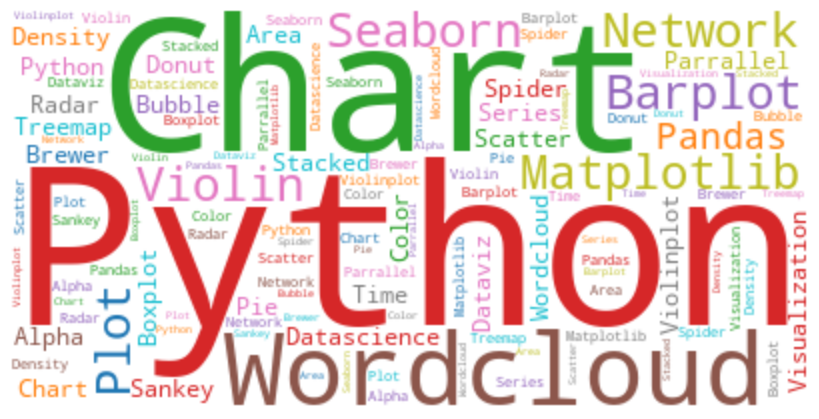

In [44]:
wc = WordCloud(
    background_color="white",
    
    repeat=True,            # Repeats text to fill the bulb density nicely
    colormap="tab10",    # Try: "inferno", "tab10", "YlOrBr_r", "cool"
    contour_width=2,        # Draws a light bulb border
    contour_color="#3fe316",
    min_font_size=4,
    max_words=350,
    random_state=42
).generate(text)

# 5. Display and save the plot
plt.figure(figsize=(8, 6), facecolor='white')
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig("lightbulb_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

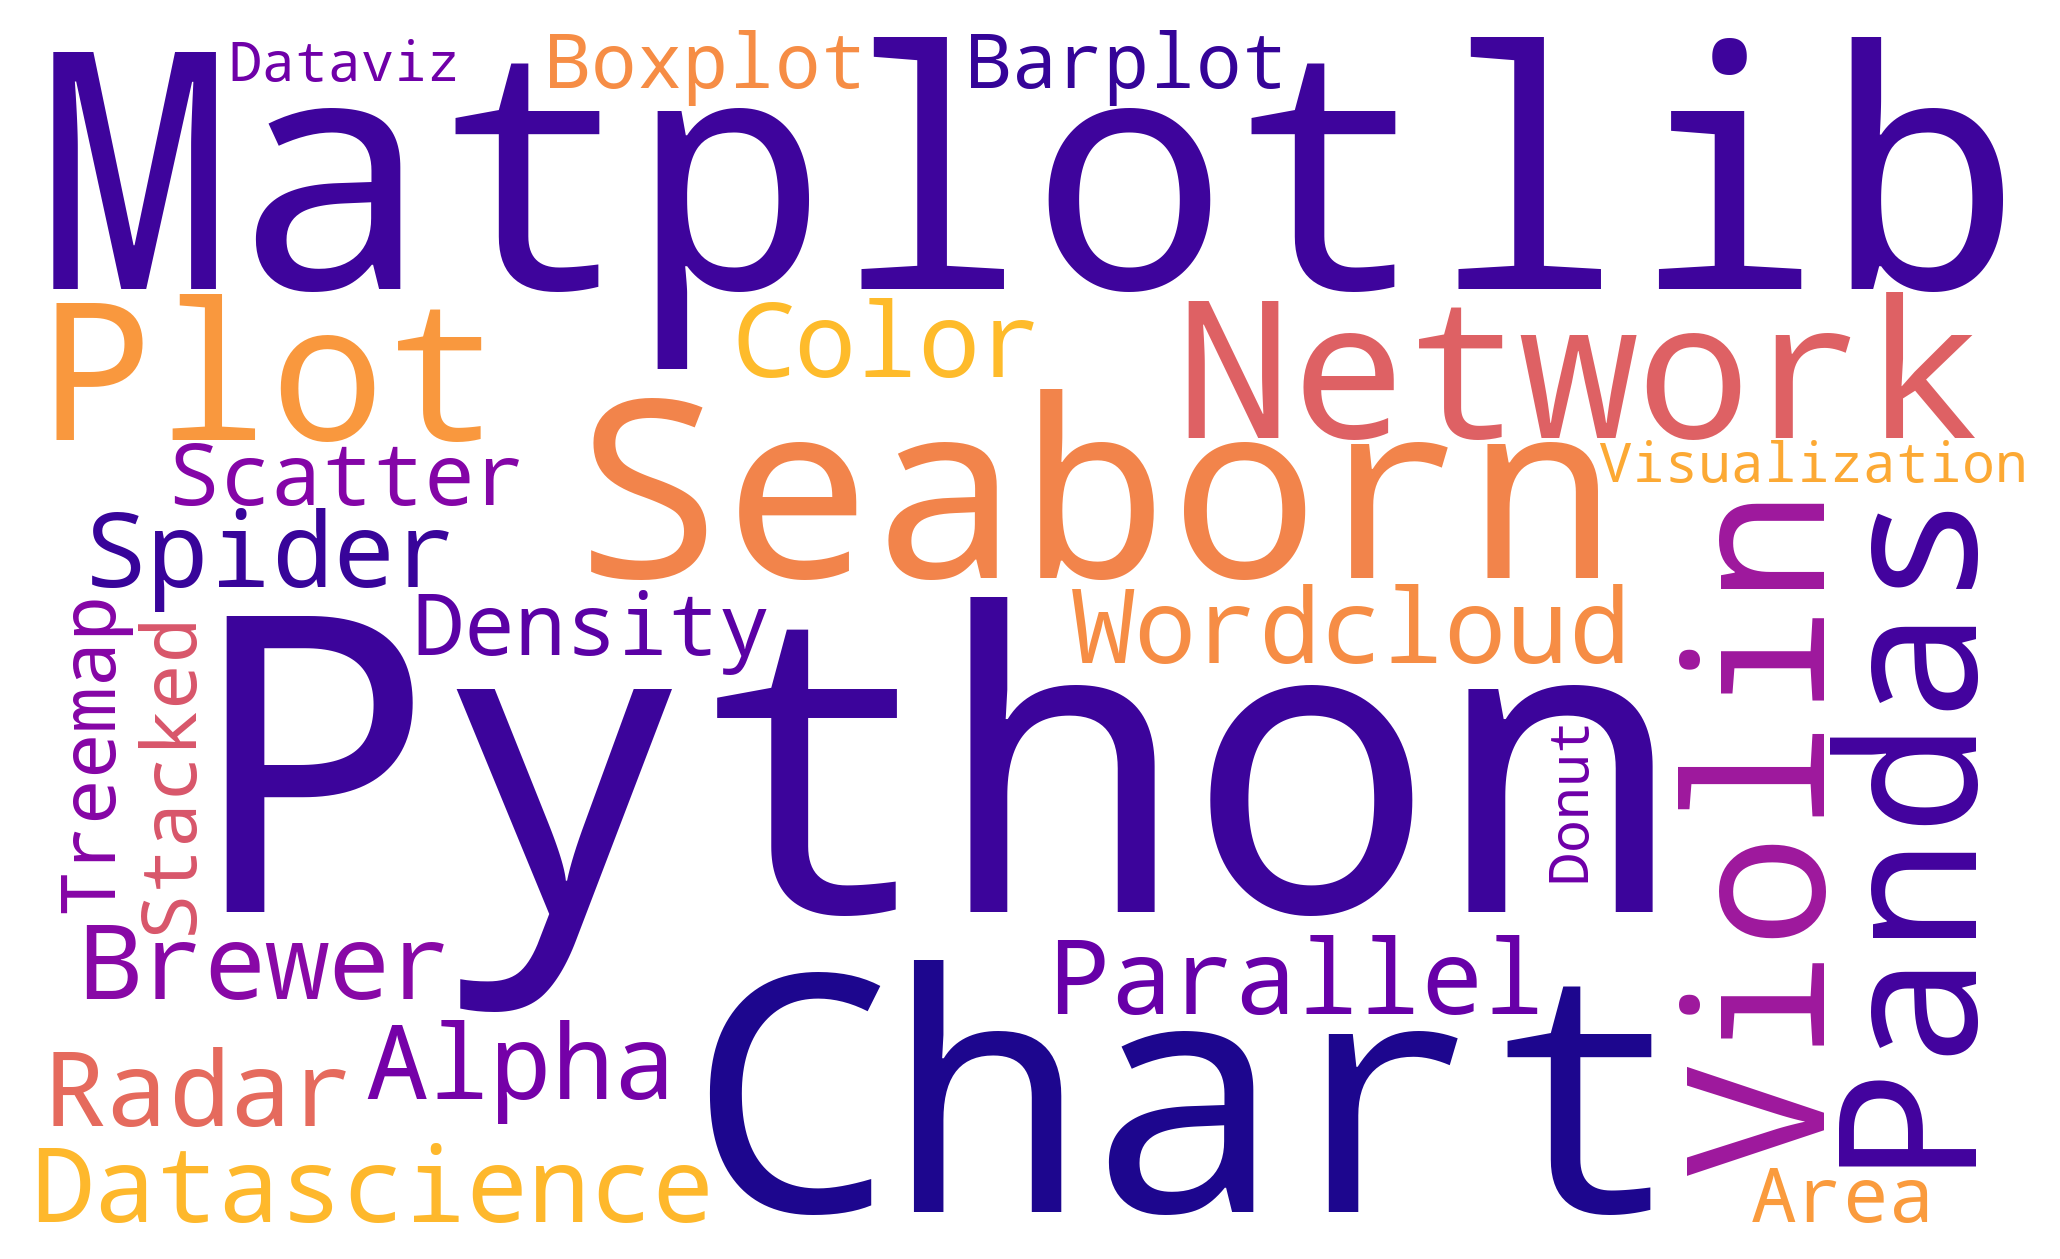

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

text = ("Python Python Python Matplotlib Matplotlib Seaborn Network Plot Violin Chart "
        "Pandas Datascience Wordcloud Spider Radar Parallel Alpha Color Brewer Density "
        "Scatter Barplot Boxplot Treemap Stacked Area Chart Visualization Dataviz Donut")

# 1. GENERATE AT HIGH RESOLUTION
# Generate at 2000x1200 resolution so fonts render with sharp anti-aliasing
wc = WordCloud(
    width=2000,              # High width
    height=1200,             # High height
    background_color="white",
    colormap="plasma",
    
    # 2. FONT SMOOTHING SETTINGS
    # You can pass a path to any high-quality .ttf/.otf font on your system
    # font_path="arial.ttf", # e.g., "C:/Windows/Fonts/arial.ttf" or "/Library/Fonts/Arial.ttf"
    
    min_font_size=12,        # Prevents tiny, pixelated words
    prefer_horizontal=0.9,   # Horizontal text is easier to render cleanly
    relative_scaling=0.5,    # Balances frequency vs font sizing smoothly
    random_state=42
).generate(text)

# 3. DISPLAY SMOOTHLY IN MATPLOTLIB
# Match figure proportions to width/height ratio (2000:1200 -> 10:6)
plt.figure(figsize=(8, 4), dpi=300) # High DPI for rendering
plt.imshow(wc, interpolation="bilinear") # Bilinear smoothing
plt.axis("off")
plt.tight_layout(pad=0)

# 4. SAVE AT HIGH RESOLUTION
# dpi=300 prevents Matplotlib from compressing or rasterizing the output down
plt.savefig("smooth_wordcloud.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()

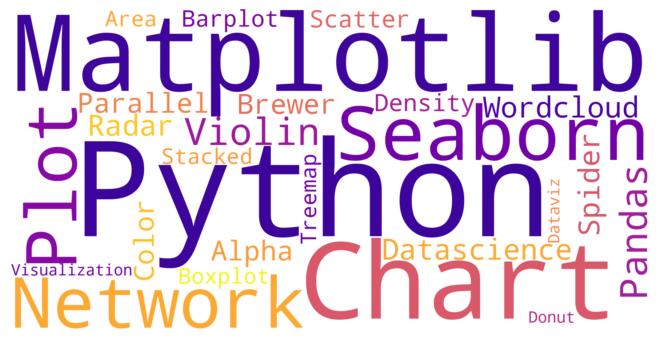

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

text = ("Python Python Python Matplotlib Matplotlib Seaborn Network Plot Violin Chart "
        "Pandas Datascience Wordcloud Spider Radar Parallel Alpha Color Brewer Density "
        "Scatter Barplot Boxplot Treemap Stacked Area Chart Visualization Dataviz Donut")

# 1. GENERATE AT HIGH RESOLUTION
# Generate at 2000x1200 resolution so fonts render with sharp anti-aliasing
wc = WordCloud(
   width=2400,             # ✅ FIXED: Native 2400px width
    height=1200,            # ✅ FIXED: Native 1200px height
    background_color="white",
    colormap="plasma",
    min_font_size=12,       # ✅ Scaled up for higher resolution canvas

    # 2. FONT SMOOTHING SETTINGS
    # You can pass a path to any high-quality .ttf/.otf font on your system
    # font_path="arial.ttf", # e.g., "C:/Windows/Fonts/arial.ttf" or "/Library/Fonts/Arial.ttf"
    
    # min_font_size=6,        # Prevents tiny, pixelated words
    prefer_horizontal=0.9,   # Horizontal text is easier to render cleanly
    relative_scaling=0.5,    # Balances frequency vs font sizing smoothly
    random_state=42
).generate(text)

# 3. DISPLAY SMOOTHLY IN MATPLOTLIB
# Match figure proportions to width/height ratio (2000:1200 -> 10:6)

# plt.figure(figsize=(10,6), dpi=300) # High DPI for rendering
plt.imshow(wc, interpolation="bilinear") # Bilinear smoothing
plt.axis("off")
plt.tight_layout(pad=0)

# 4. SAVE AT HIGH RESOLUTION
# dpi=300 prevents Matplotlib from compressing or rasterizing the output down
plt.savefig("smooth_wordcloud.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()